# Agilent and Keysight Binary Waveform Examples

**Scott Prahl**

**Mar 2026**

In [1]:
%config InlineBackend.figure_format = 'retina'

import io

import numpy as np
import matplotlib.pyplot as plt
import requests
from RigolWFM import Wfm

repo = 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/'

def sample_url(relative_path: str) -> str:
    return repo + relative_path

def _time_scale(times):
    span = float(abs(times[-1] - times[0])) if len(times) > 1 else 1.0
    if span >= 1e-3:
        return 1e3, 'ms'
    if span >= 1e-6:
        return 1e6, 'us'
    if span >= 1e-9:
        return 1e9, 'ns'
    return 1e12, 'ps'

def _volt_scale(values):
    peak = max(float(np.max(np.abs(v))) for v in values) if values else 1.0
    if peak >= 1.0:
        return 1.0, 'V'
    if peak >= 1e-3:
        return 1e3, 'mV'
    if peak >= 1e-6:
        return 1e6, 'uV'
    return 1e9, 'nV'

def plot_analog_channels(w, title=None, max_points=5000):
    active = [ch for ch in w.channels if ch.times is not None and ch.volts is not None]
    if not active:
        print('No analog channels are enabled in this capture.')
        return

    colors = ['green', 'red', 'blue', 'orange']
    t_scale, t_unit = _time_scale(active[0].times)
    v_scale, v_unit = _volt_scale([ch.volts for ch in active])

    fig, axes = plt.subplots(len(active), 1, sharex=True, figsize=(10, 2.5 * len(active)))
    if len(active) == 1:
        axes = [axes]

    for ax, ch, color in zip(axes, active, colors):
        stride = max(len(ch.times) // max_points, 1)
        ax.plot(ch.times[::stride] * t_scale, ch.volts[::stride] * v_scale, color=color)
        ax.set_ylabel(v_unit)
        ax.set_title(f'CH{ch.channel_number}  {ch.points} points')
        ax.grid(True)

    axes[-1].set_xlabel(f'Time ({t_unit})')
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()

def plot_logic_window(w, names=None, start=0, stop=4000, title=None):
    if not w.logic_channels:
        print('No logic channels are enabled in this capture.')
        return

    if names is None:
        names = list(w.logic_channels)

    if w.logic_times is None:
        times = np.arange(len(next(iter(w.logic_channels.values()))), dtype=np.float64)
    else:
        times = w.logic_times

    stop = min(stop, len(times))
    t_scale, t_unit = _time_scale(times[start:stop])

    fig, axes = plt.subplots(len(names), 1, sharex=True, figsize=(10, 1.6 * len(names)))
    if len(names) == 1:
        axes = [axes]

    colors = ['green', 'red', 'blue', 'orange', 'purple', 'brown']
    for ax, name, color in zip(axes, names, colors):
        trace = w.logic_channels[name]
        ax.step(times[start:stop] * t_scale, trace[start:stop], where='post', color=color)
        ax.set_ylim(-0.2, 1.2)
        ax.set_yticks([0, 1])
        ax.set_ylabel(name)
        ax.grid(True)

    axes[-1].set_xlabel(f'Time ({t_unit})')
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


## `agilent_1.bin` - Single-channel analog capture

### Oscilloscope screenshot

<img src="https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/bin/agilent_1.png" width="60%">

In [2]:
filename = 'bin/agilent_1.bin'
w = Wfm.from_url(sample_url(filename), 'Keysight')
print(w.describe())

    General:
        File Model   = DSO-X 1102G
        Serial Number = CN00000000
        User Model   = Keysight
        Parser Model = agilent_bin
        Firmware     = unknown
        Filename     = agilent_1.bin
        Channels     = [1]

    Trigger:
        Derived Level (CH1) = -80.40 mV

     Channel 1:
         Coupling =  unknown
            Scale =   502.51 mV/div
           Offset =     0.00  V
            Probe =       1X
         Inverted =    False

        Time Base =  100.000 µs/div
           Offset =    0.000  s
            Delta =  500.000 ns/point
           Points =     2000

         Count    = [        1,        2,        3  ...      1999,     2000]
           Raw    = [        5,        3,        5  ...         5,        8]
           Times  = [-500.063 µs,-499.563 µs,-499.063 µs  ... 498.937 µs,499.437 µs]
           Volts  = [  1.85  V,  1.89  V,  1.85  V  ...   1.85  V,  1.81  V]




downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/bin/agilent_1.bin'


### Plot the decoded channel

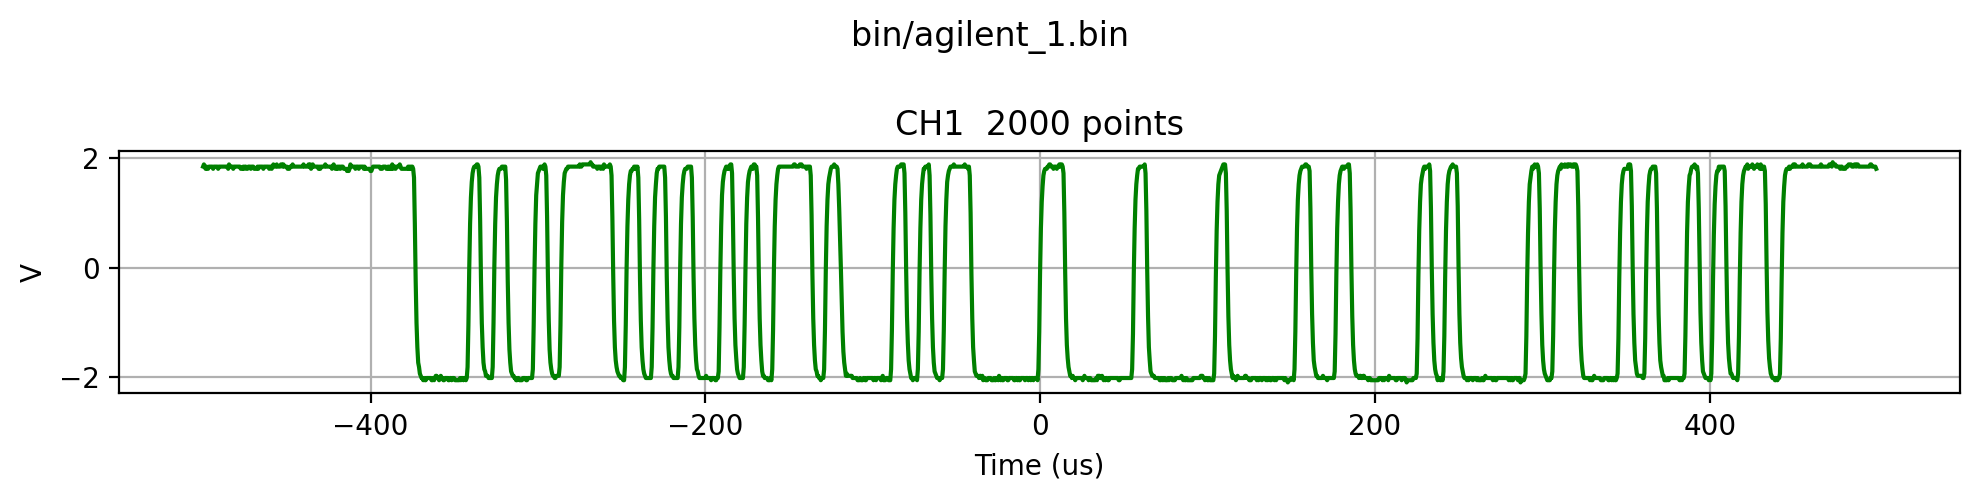

In [3]:
plot_analog_channels(w, title=filename)

## `agilent_3.bin` - Two-channel capture

### Oscilloscope screenshot

<img src="https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/bin/agilent_3.png" width="60%">

In [4]:
filename = 'bin/agilent_3.bin'
w = Wfm.from_url(sample_url(filename), 'Keysight')
print(w.describe())

    General:
        File Model   = DSO-X 1102G
        Serial Number = CN00000000
        User Model   = Keysight
        Parser Model = agilent_bin
        Firmware     = unknown
        Filename     = agilent_3.bin
        Channels     = [1, 2]

    Trigger:
        Derived Level (CH1) = 180.90 mV
        Derived Level (CH2) = -1.22  V

     Channel 1:
         Coupling =  unknown
            Scale =   703.52 mV/div
           Offset =     0.00  V
            Probe =       1X
         Inverted =    False

        Time Base =  200.000 ns/div
           Offset =    0.000  s
            Delta =  500.000 ps/point
           Points =     4000

         Count    = [        1,        2,        3  ...      3999,     4000]
           Raw    = [      116,      116,      116  ...       116,      116]
           Times  = [-1.000 µs,-999.500 ns,-999.000 ns  ... 999.000 ns,999.500 ns]
           Volts  = [180.90 mV,180.90 mV,180.90 mV  ... 180.90 mV,180.90 mV]

     Channel 2:
         Coupling =

downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/bin/agilent_3.bin'


### Plot both enabled channels

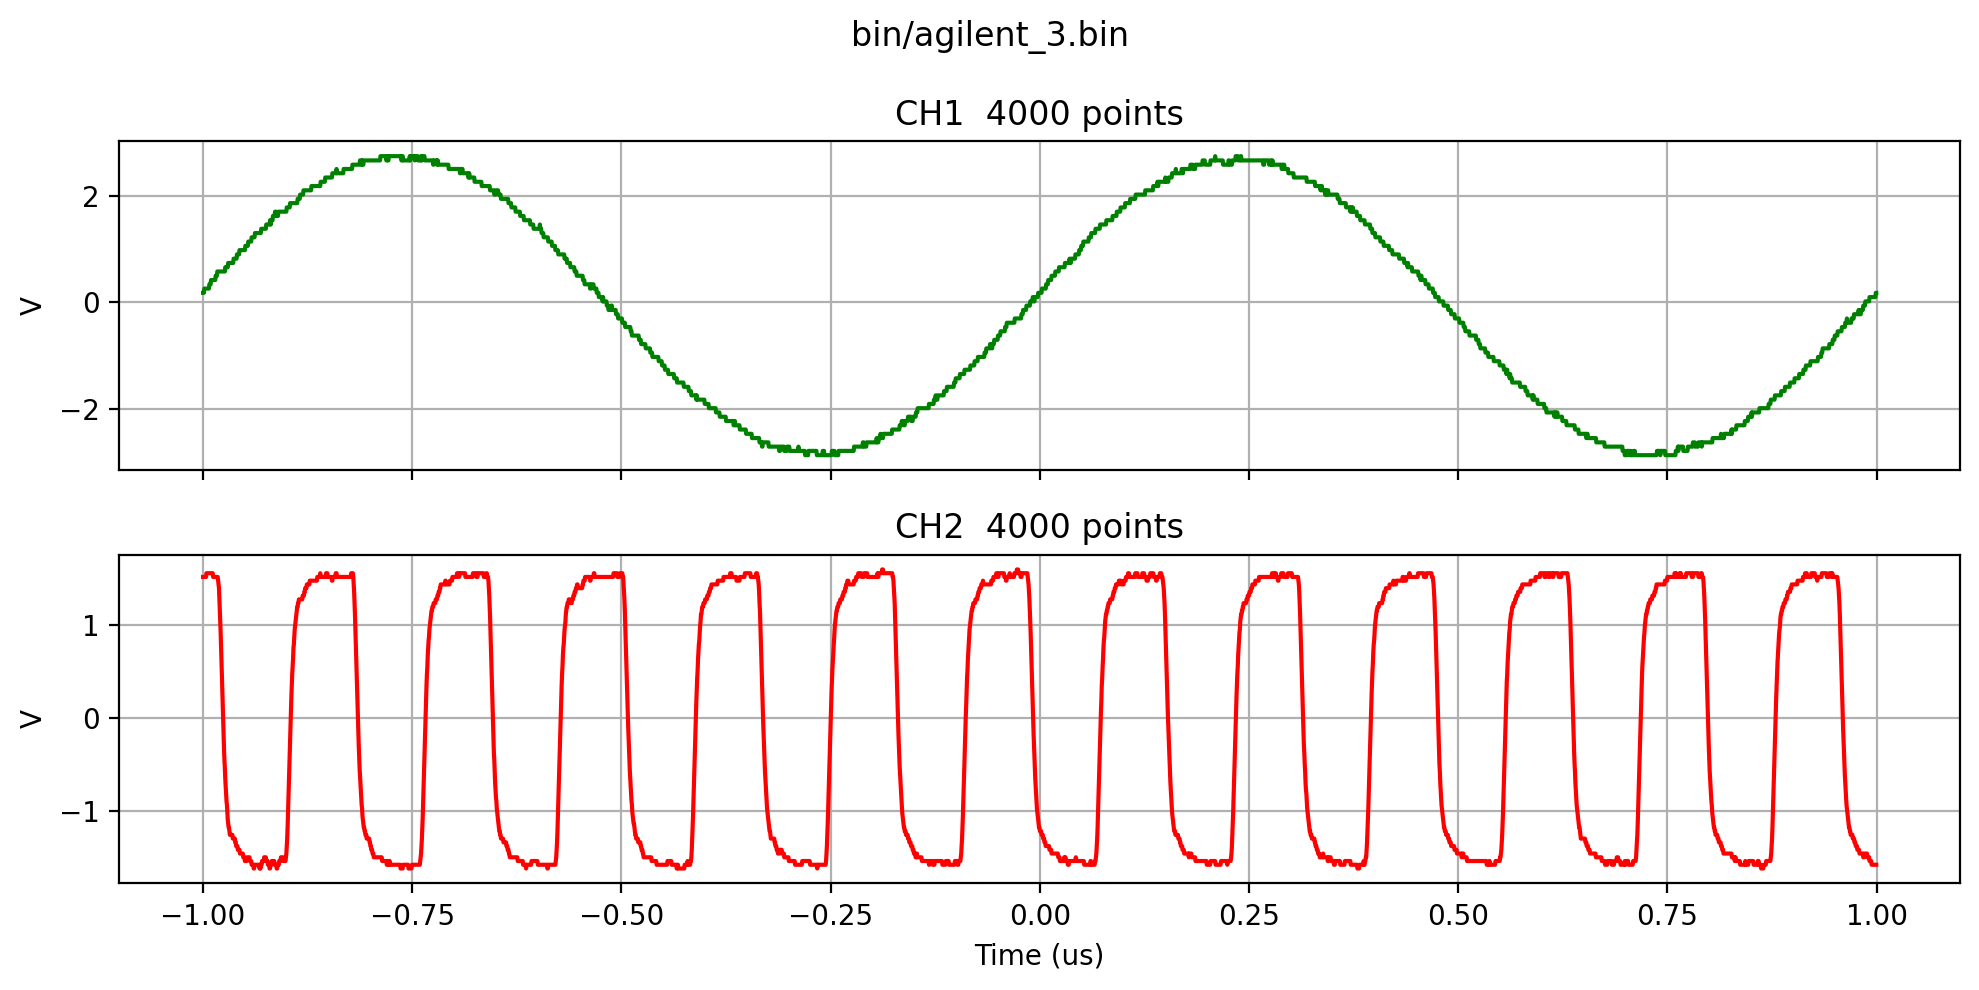

In [5]:
plot_analog_channels(w, title=filename)

## `agilent_msox4154a_01.bin` - Four-channel MSO-X capture

This file is much larger than the small demo fixtures, so the plot below is decimated for readability.

In [6]:
filename = 'bin/agilent_msox4154a_01.bin'
w = Wfm.from_url(sample_url(filename), 'Keysight')
print(w.describe())

downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/bin/agilent_msox4154a_01.bin'


    General:
        File Model   = MSO-X 4154A
        Serial Number = MY00000000
        User Model   = Keysight
        Parser Model = agilent_bin
        Firmware     = unknown
        Filename     = agilent_msox4154a_01.bin
        Channels     = [1, 2, 3, 4]

    Trigger:
        Derived Level (CH1) = -57.75  V
        Derived Level (CH2) = 13.39  V
        Derived Level (CH3) = -901.82 mV
        Derived Level (CH4) = 377.09 mV

     Channel 1:
         Coupling =  unknown
            Scale =    78.24  V/div
           Offset =     0.00  V
            Probe =       1X
         Inverted =    False

        Time Base =  200.000 µs/div
           Offset =    0.000  s
            Delta =  800.000 ps/point
           Points =  2000000

         Count    = [        1,        2,        3  ...   1999999,  2000000]
           Raw    = [       26,       24,       24  ...       225,      227]
           Times  = [-826.613 µs,-826.612 µs,-826.611 µs  ... 773.386 µs,773.386 µs]
           Vo

### Plot all four channels

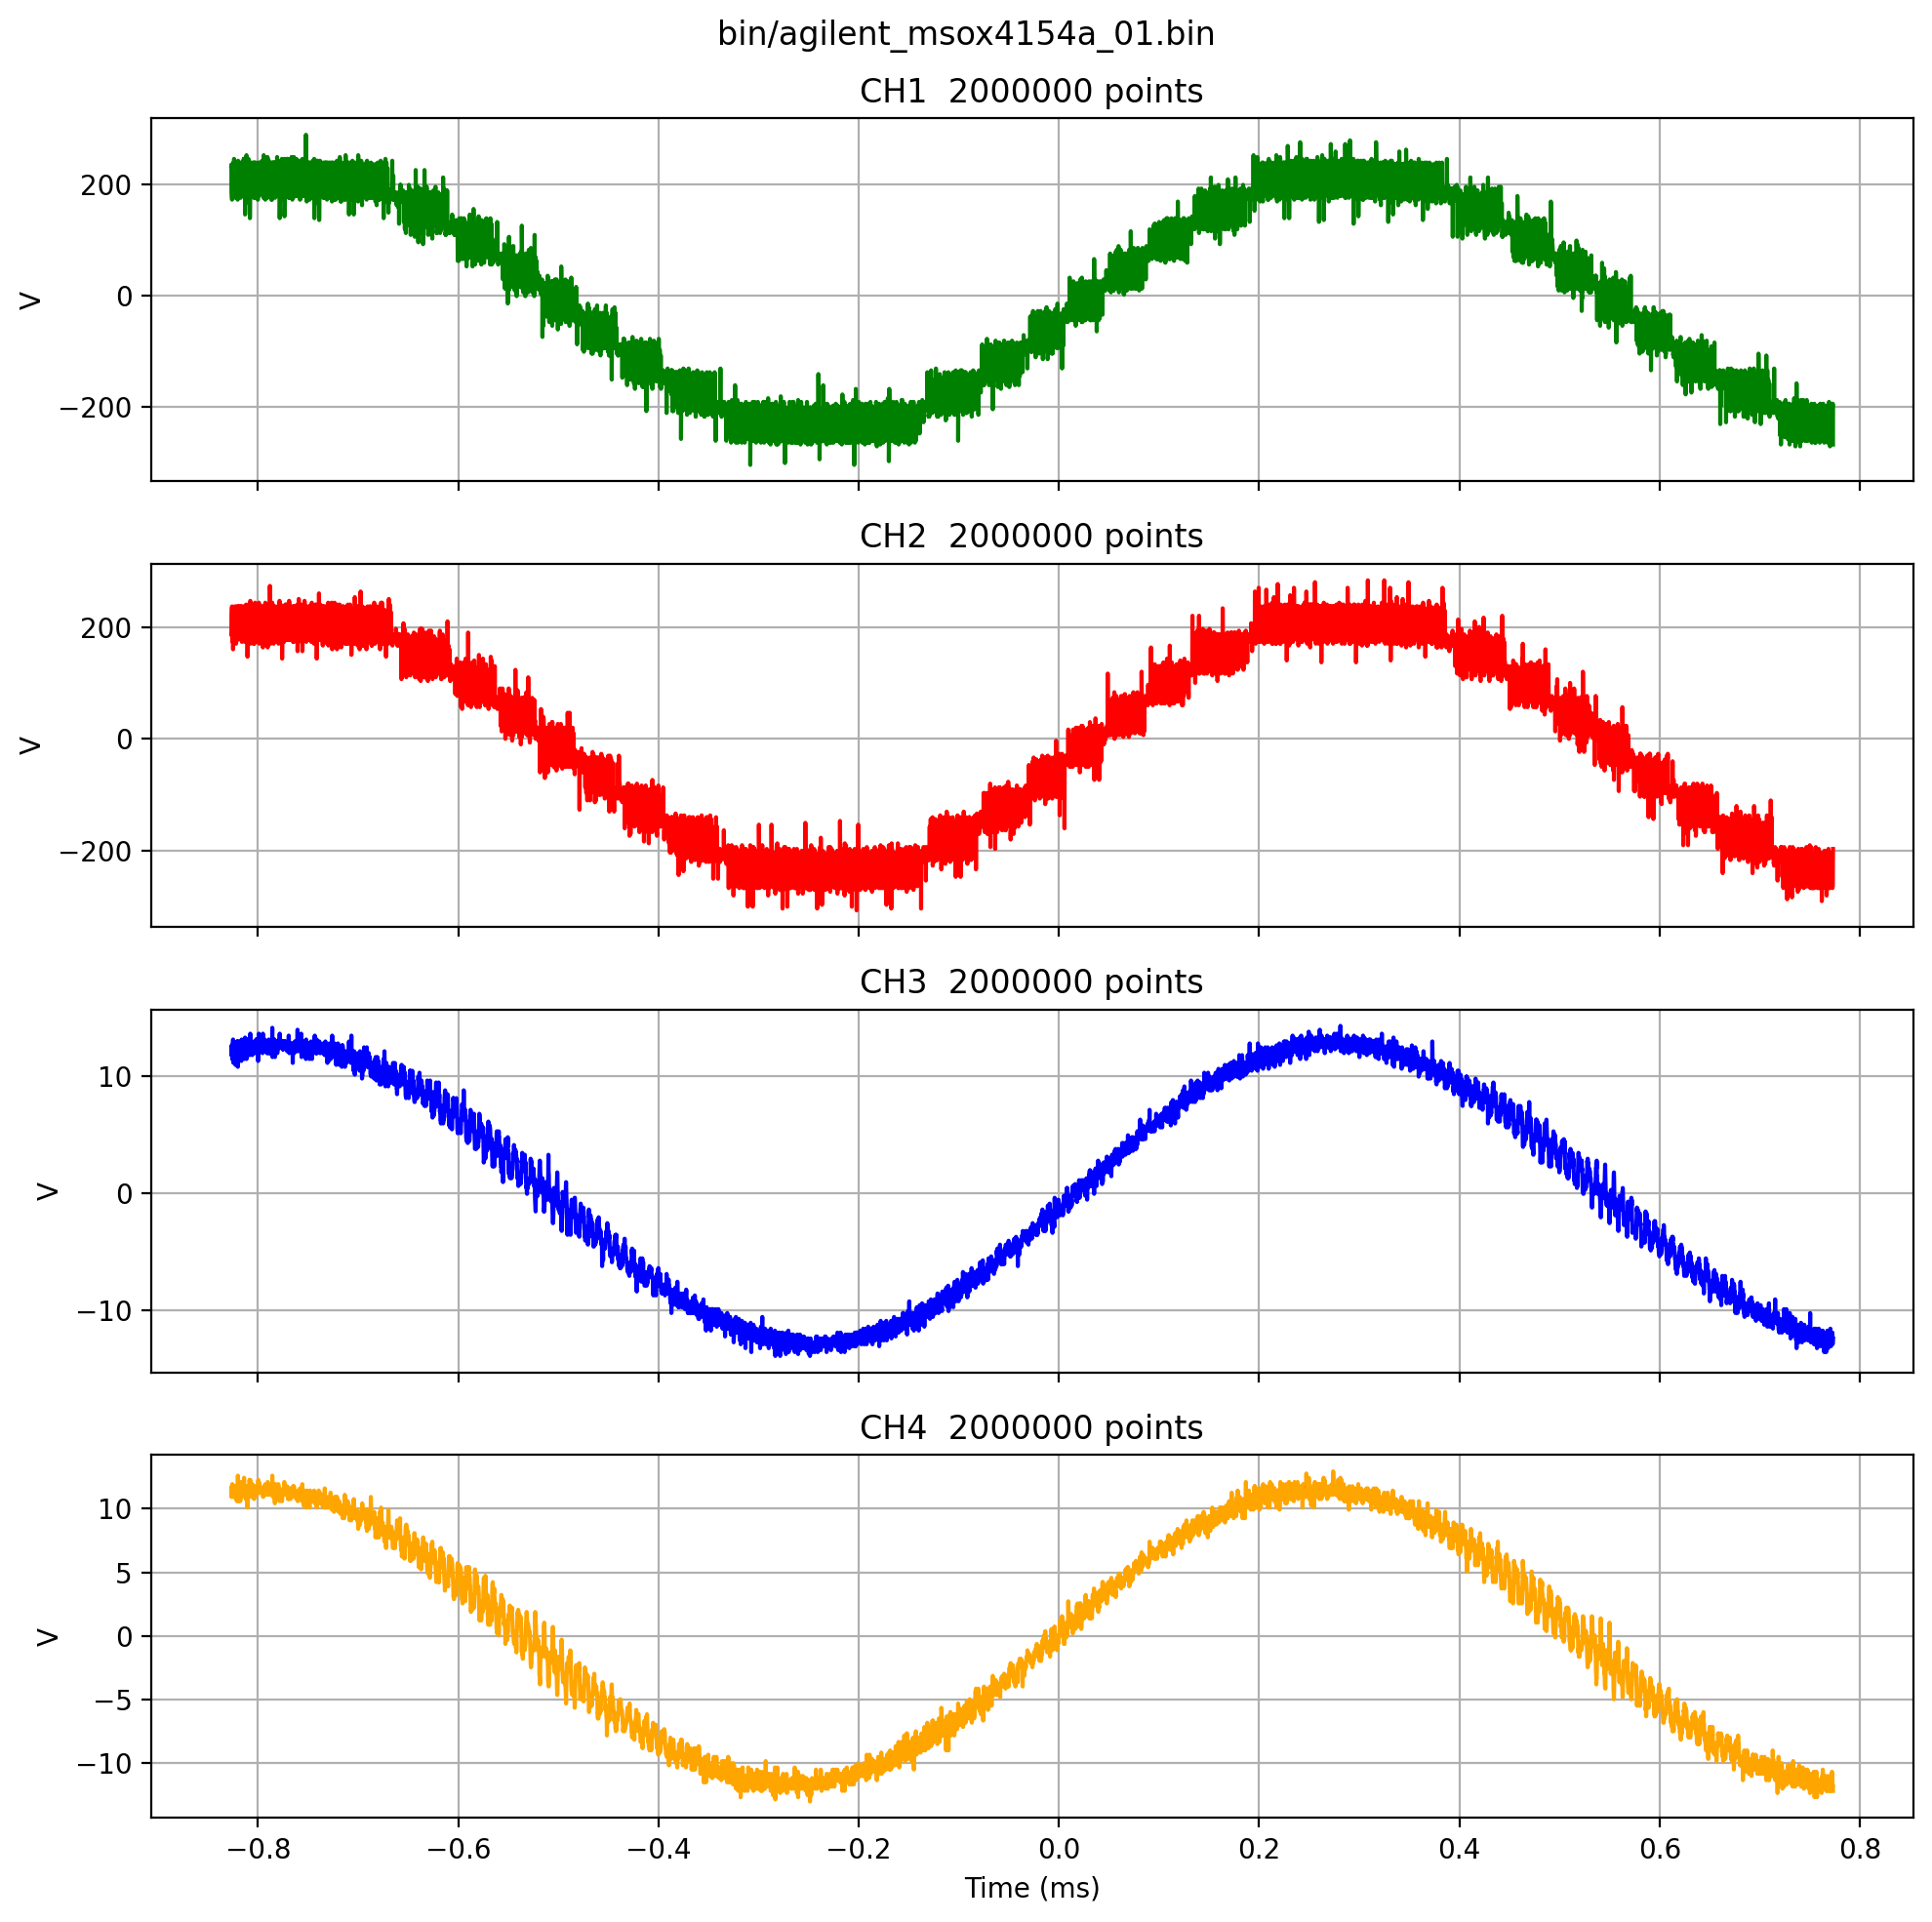

In [7]:
plot_analog_channels(w, title=filename, max_points=8000)